## 자연어 처리는 숫자화, 벡터화해야 한다
- ex) '안녕 반가워' : [0,1,0,1,1,0] 또는 [0.12, 0.03, 0.56, 0.23]처럼 변경해서 작업
### 자연어 처리의 흐름
- 문장 -> 단어 분리 -> 숫자화 -> 모델 또는 분석 -> 결과 예측
- 방법 : onehot, WordVec, ConutVectorizer, TfidfVectorizer, BERT, ...

In [38]:
# onehot encoding - 문자 데이터를 0과 1로
datas = ['python', 'lan', 'program', 'computer', 'say']
sorted_datas = sorted(datas)
print('정렬된 결과 : ', sorted_datas)

manual_labels = list(range(len(sorted_datas)))
print('인덱싱 :', manual_labels)
print()

# numpy.eye() 사용
import numpy as np
onehot_menual = np.eye(len(sorted_datas))
print('numpy.eye() 사용 :',onehot_menual)
print()

# sklearn.LabelEncoder사용
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
encoded_labels = encoder.fit_transform(datas)
print('정렬된 고유 클래스 목록 :',sorted_datas)
print('sklearn.LabelEncoder 인코딩된 결과 :', encoded_labels)
print('디코딩 결과',encoder.inverse_transform(encoded_labels))
print()

# sklearn.OenHotEncoder 사용
from sklearn.preprocessing import OneHotEncoder
sorted_datas_2d = np.array(sorted_datas).reshape(-1,1)
onehot_encoder = OneHotEncoder()
onehot_labels = onehot_encoder.fit_transform(sorted_datas_2d)
print('sklearn.OenHotEncoder 결과 :\n',onehot_labels.toarray())
# 복원
decoded_label = onehot_encoder.inverse_transform(onehot_labels).ravel()
print('Decodeing 결과 :',decoded_label)
print()

# pandas.DataFrame사용
import pandas as pd
df = pd.DataFrame({'datas':sorted_datas})
onehot_df = pd.get_dummies(df, dtype=int)
print('pandas.DataFrame 사용 : \n',onehot_df.values)

정렬된 결과 :  ['computer', 'lan', 'program', 'python', 'say']
인덱싱 : [0, 1, 2, 3, 4]

numpy.eye() 사용 : [[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]

정렬된 고유 클래스 목록 : ['computer', 'lan', 'program', 'python', 'say']
sklearn.LabelEncoder 인코딩된 결과 : [3 1 2 0 4]
디코딩 결과 ['python' 'lan' 'program' 'computer' 'say']

sklearn.OenHotEncoder 결과 :
 [[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]
Decodeing 결과 : ['computer' 'lan' 'program' 'python' 'say']

pandas.DataFrame 사용 : 
 [[1 0 0 0 0]
 [0 1 0 0 0]
 [0 0 1 0 0]
 [0 0 0 1 0]
 [0 0 0 0 1]]


In [39]:
# 밀집벡터 - 0이 아닌 숫자로 채워진 벡터
# Ward2Vec : 주어진 문맥을 바탕으로 특정 단어를 예측하여 벡터로 변환 - 코사인유사도로 단어간 의미 파악
# !pip install gensim
from gensim.models import Word2Vec # 어떤 단어가 어떤 단어들과 자주 등장하는지를 보고 의미를 학습.

sentences = [['king', 'queen', 'man', 'woman'], ['apple', 'banana', 'fruit']]
model = Word2Vec(sentences=sentences, vector_size=10, window=2, min_count=1, sg=1)
# sg = 모델 학습방법을 결정
# sg = 0 : CBOW(Continuous Ba Of Words) - 주변단어를 이용해 중심단어를 예측
# sg = 1 : Skip-Gram - 중심단어를 이용해 주변 단어를 예측
print(model.wv)
print(model.wv['king']) # 임베딩 벡터
print(model.wv.similarity('king', 'queen')) # 유사도(두 단어가 코사인 유사도) 계산 결과
print(model.wv.similarity('king', 'man'))  # -1 ~ 1 (1에 근사: 의미가 비슷, 0:관련 없음, -1: 반대 의미)
print(model.wv.similarity('apple','man'))

print(model.wv.most_similar('king'))
print(model.wv.most_similar('apple', topn=2))
print()

KeyedVectors<vector_size=10, 7 keys>
[-0.01577653  0.00321372 -0.0414063  -0.07682689 -0.01508008  0.02469795
 -0.00888027  0.05533662 -0.02742977  0.02260065]
-0.042645365
0.6143981
-0.3207966
[('man', 0.614398181438446), ('queen', -0.04264536499977112), ('apple', -0.08937527239322662), ('woman', -0.11387497186660767), ('banana', -0.1799870878458023), ('fruit', -0.1897382289171219)]
[('banana', 0.32937225699424744), ('fruit', 0.3004249036312103)]



In [41]:
sentences2 = [['python','lan','program','computer','say']]
model2 = Word2Vec(sentences=sentences2, vector_size=10, window=2, min_count=1, sg=1, alpha=0.025)
print('인덱스 사전:', model2.wv.key_to_index)
print('keys : ', model2.wv.key_to_index.keys())
print('valuse : ',model2.wv.key_to_index.values())
print()
vocabs = model2.wv.key_to_index.keys()
wordvec_list = [model2.wv[i] for i in vocabs]
# print(vocabs)
# print(wordvec_list)
print(wordvec_list[0])
print()

for word in vocabs:
  print(word, model2.wv[word])
print()

print(model2.wv.similarity(w1='python',w2='lan')) # -0.36627138
# 'python'과 가장 유사한 단어 2개
print(model2.wv.most_similar('python', topn=2))
print(np.degrees(np.arccos(-0.3207966387271881)))


인덱스 사전: {'say': 0, 'computer': 1, 'program': 2, 'lan': 3, 'python': 4}
keys :  dict_keys(['say', 'computer', 'program', 'lan', 'python'])
valuse :  dict_values([0, 1, 2, 3, 4])

[-0.00536227  0.00236431  0.0510335   0.09009273 -0.0930295  -0.07116809
  0.06458873  0.08972988 -0.05015428 -0.03763372]

say [-0.00536227  0.00236431  0.0510335   0.09009273 -0.0930295  -0.07116809
  0.06458873  0.08972988 -0.05015428 -0.03763372]
computer [ 0.07380505 -0.01533471 -0.04536613  0.06554051 -0.0486016  -0.01816018
  0.0287658   0.00991874 -0.08285215 -0.09448818]
program [ 0.07311766  0.05070262  0.06757693  0.00762866  0.06350891 -0.03405366
 -0.00946401  0.05768573 -0.07521638 -0.03936104]
lan [-0.07511582 -0.00930042  0.09538119 -0.07319167 -0.02333769 -0.01937741
  0.08077437 -0.05930896  0.00045162 -0.04753734]
python [-0.0960355   0.05007293 -0.08759586 -0.04391825 -0.000351   -0.00296181
 -0.0766124   0.09614743  0.04982058  0.09233143]

-0.36627138
[('say', -0.22418658435344696), ('prog

[[-0.07405484  0.03239381]
 [-0.10269947  0.07159086]
 [-0.04633134  0.0379803 ]
 [-0.01086849 -0.18268013]
 [ 0.23395414  0.04071517]]


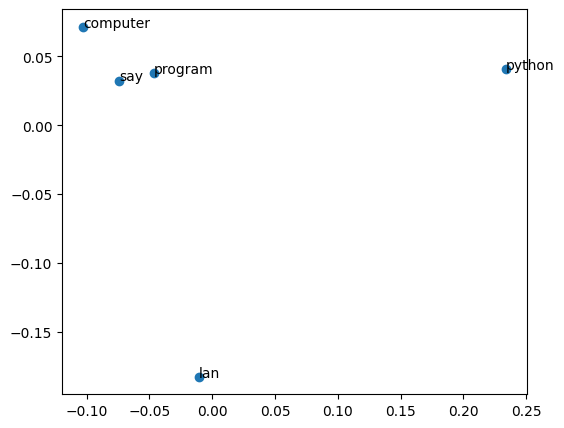

In [44]:
# 시각화
import matplotlib.pyplot as plt

def plotFunc(vocabs, x, y):
  plt.figure(figsize=(6,5))
  plt.scatter(x, y)
  for i , v in enumerate(vocabs):
    plt.annotate(v, xy=(x[i], y[i]))
  plt.show()

# 주성분 분석(PCA)으로 차원 축소 (2차원으로)
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
xytrans = pca.fit_transform(wordvec_list)
print(xytrans)
xs = xytrans[:, 0]
ys = xytrans[:, 1]
plotFunc(vocabs, xs, ys)

In [47]:
# 특정 단어에 대해 유사도 순으로 정렬하여 text로 가까운 정도 표현
target = 'python'
sim = {w:model2.wv.similarity(target, w) for w in vocabs if w != target}
sorted_sim = sorted(sim.items(), key=lambda x:x[1], reverse=True)
print(f'{target} 기준 코사인 유사도 \n')
for word, s in sorted_sim:
  bar = '■' * int((s + 1) * 10)
  print(f'{word:<10}|{bar:20}({s:.3f})')

python 기준 코사인 유사도 

say       |■■■■■■■             (-0.224)
program   |■■■■■■              (-0.321)
lan       |■■■■■■              (-0.366)
computer  |■■■■                (-0.538)
